In [1]:
import pandas as pd

df = pd.read_csv("tickets.csv")   # change path if needed
print("Rows:", df.shape)
print(df.columns)


Rows: (47837, 2)
Index(['Document', 'Topic_group'], dtype='object')


In [2]:
df["clean_text"] = (
    df["Document"]
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

df = df.dropna(subset=["clean_text", "Topic_group"])
df = df[df["clean_text"].str.len() > 30]

print("After filter:", df.shape)
print(df["Topic_group"].value_counts())


After filter: (47590, 3)
Topic_group
Hardware                 13539
HR Support               10853
Access                    7060
Miscellaneous             7039
Storage                   2772
Purchase                  2460
Internal Project          2114
Administrative rights     1753
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    df["clean_text"],
    df["Topic_group"],
    test_size=0.2,
    stratify=df["Topic_group"],
    random_state=42
)

print("Train:", len(X_train))
print("Val:", len(X_val))


Train: 38072
Val: 9518


C:\Users\dss28\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3468 - loss: 1.7587 - val_accuracy: 0.4266 - val_loss: 1.5830
Epoch 2/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4899 - loss: 1.4771 - val_accuracy: 0.6011 - val_loss: 1.2359
Epoch 3/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6116 - loss: 1.1997 - val_accuracy: 0.6077 - val_loss: 1.2210
Epoch 4/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6053 - loss: 1.1883 - val_accuracy: 0.6018 - val_loss: 1.2236
Epoch 5/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6358 - loss: 1.1321 - val_accuracy: 0.6175 - val_loss: 1.1675
Epoch 6/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6537 - loss: 1.0709 - val_accuracy: 0.6332 - val_loss: 1.1269
Epoch 7/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6684 - loss: 1.0412 - val_accuracy: 0.6422 - val_loss: 1.1204
Epoch 8/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6915 - loss: 0.9723 - 

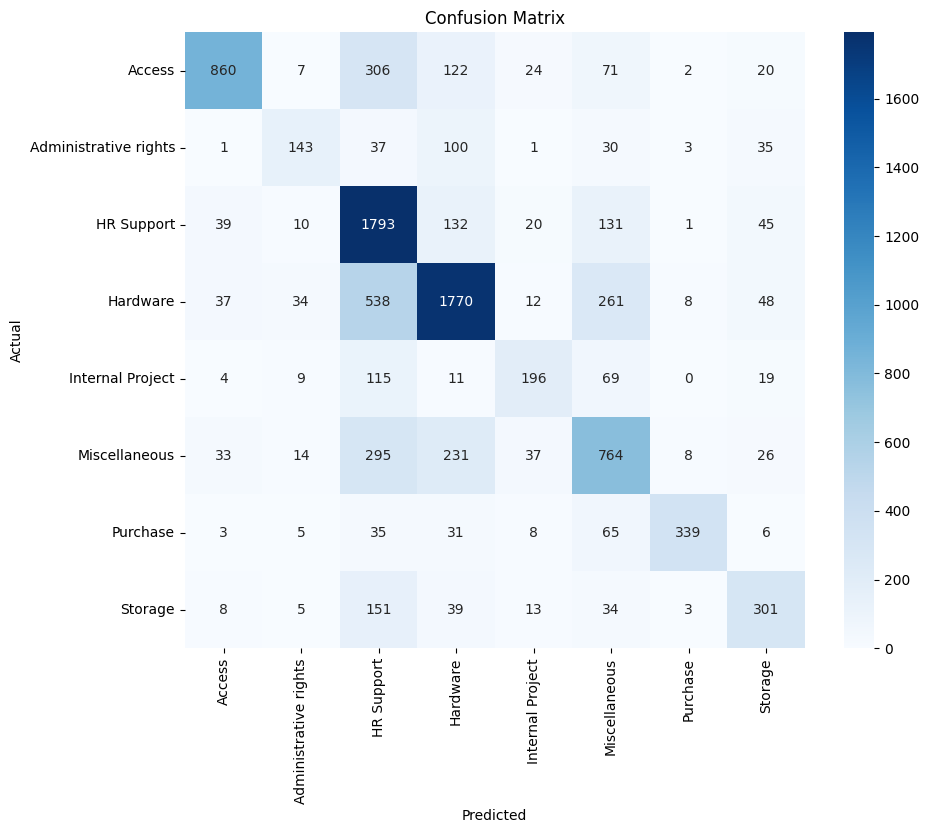

In [4]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# Parameters
# -----------------------------
vocab_size = 5000      # max number of words
max_len = 50           # max tokens per text
embedding_dim = 50
rnn_units = 64
batch_size = 32
epochs = 10

# -----------------------------
# Tokenize text
# -----------------------------
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')

# -----------------------------
# Encode labels
# -----------------------------
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_val_int = label_encoder.transform(y_val)

num_classes = len(label_encoder.classes_)
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train_int, num_classes)
y_val_cat = to_categorical(y_val_int, num_classes)

# -----------------------------
# Compute class weights
# -----------------------------
class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights = dict(enumerate(class_weights_values))

# -----------------------------
# Build RNN model
# -----------------------------
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    SimpleRNN(rnn_units),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# Early stopping
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# -----------------------------
# Train model with class weights
# -----------------------------
history = model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    batch_size=batch_size,
    epochs=epochs,
    # class_weight=class_weights,
    # callbacks=[early_stop]
)

# -----------------------------
# Evaluate
# -----------------------------
val_loss, val_acc = model.evaluate(X_val_pad, y_val_cat)
print(f"Validation Accuracy: {val_acc:.4f}")

# -----------------------------
# Confusion matrix
# -----------------------------
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_labels = np.argmax(model.predict(X_val_pad), axis=1)
y_val_labels = np.argmax(y_val_cat, axis=1)

print(classification_report(y_val_labels, y_pred_labels, target_names=label_encoder.classes_))

cm = confusion_matrix(y_val_labels, y_pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


C:\Users\dss28\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3813 - loss: 1.6864 - val_accuracy: 0.5062 - val_loss: 1.3998
Epoch 2/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4778 - loss: 1.4800 - val_accuracy: 0.5120 - val_loss: 1.3737
Epoch 3/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5304 - loss: 1.3330 - val_accuracy: 0.5773 - val_loss: 1.2416
Epoch 4/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6000 - loss: 1.1770 - val_accuracy: 0.6211 - val_loss: 1.1334
Epoch 5/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6368 - loss: 1.0861 - val_accuracy: 0.6454 - val_loss: 1.1047
Epoch 6/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6685 - loss: 1.0094 - val_accuracy: 0.6713 - val_loss: 1.0282
Epoch 7/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6742 - loss: 0.9947 - val_accuracy: 0.6684 - val_loss: 1.0428
Epoch 8/10
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6568 - l

C:\Users\dss28\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dss28\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dss28\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

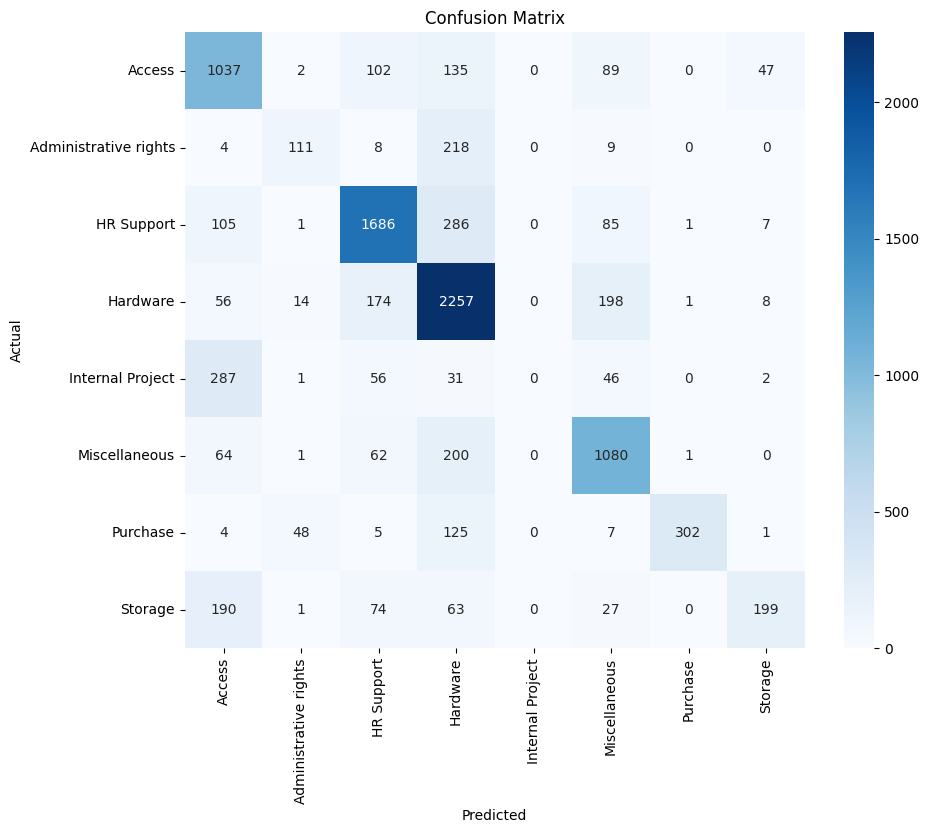

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Parameters
# -----------------------------
vocab_size = 5000
max_len = 50
embedding_dim = 50
rnn_units = 64
batch_size = 32
epochs = 10

# -----------------------------
# Tokenize text
# -----------------------------
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')

# -----------------------------
# Encode labels
# -----------------------------
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_val_int = label_encoder.transform(y_val)

num_classes = len(label_encoder.classes_)

y_train_cat = to_categorical(y_train_int, num_classes)
y_val_cat = to_categorical(y_val_int, num_classes)

# -----------------------------
# Build STACKED RNN model
# -----------------------------
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    ),

    SimpleRNN(
        rnn_units,
        return_sequences=True
    ),

    SimpleRNN(
        rnn_units
    ),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# Early stopping
# -----------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# -----------------------------
# Train model
# -----------------------------
history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=epochs,
    batch_size=batch_size,
    # callbacks=[early_stop]
)

# -----------------------------
# Evaluate
# -----------------------------
val_loss, val_acc = model.evaluate(X_val_pad, y_val_cat)
print(f"Validation Accuracy: {val_acc:.4f}")

# -----------------------------
# Report + Confusion Matrix
# -----------------------------
y_pred = np.argmax(model.predict(X_val_pad), axis=1)
y_true = np.argmax(y_val_cat, axis=1)

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


C:\Users\dss28\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.1590 - loss: 1.9689 - val_accuracy: 0.4573 - val_loss: 1.3448
Epoch 2/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.5788 - loss: 0.8969 - val_accuracy: 0.7740 - val_loss: 0.7181
Epoch 3/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8053 - loss: 0.4837 - val_accuracy: 0.7980 - val_loss: 0.5988
Epoch 4/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8419 - loss: 0.3721 - val_accuracy: 0.8070 - val_loss: 0.5868
Epoch 5/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8633 - loss: 0.3241 - val_accuracy: 0.8076 - val_loss: 0.5794
Epoch 6/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8759 - loss: 0.2810 - val_accuracy: 0.8202 - val_loss: 0.5683
Epoch 7/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8897 - loss: 0.2449 - val_accuracy: 0.8145 - val_loss: 0.6090
Epoch 8/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8993 -

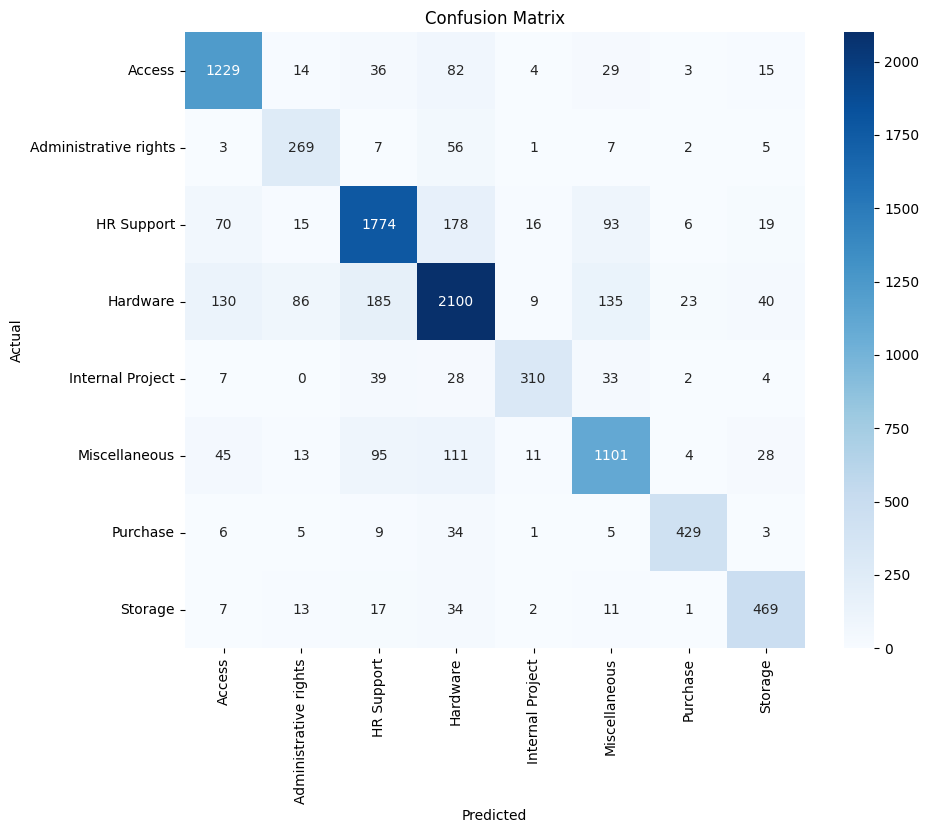

In [5]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# Parameters
# -----------------------------
vocab_size = 5000      # max number of words
max_len = 50           # max tokens per text
embedding_dim = 50
rnn_units = 64
batch_size = 32
epochs = 20

# -----------------------------
# Tokenize text
# -----------------------------
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')

# -----------------------------
# Encode labels
# -----------------------------
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_val_int = label_encoder.transform(y_val)

num_classes = len(label_encoder.classes_)
y_train_cat = to_categorical(y_train_int, num_classes)
y_val_cat = to_categorical(y_val_int, num_classes)

# -----------------------------
# Compute class weights
# -----------------------------
class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights = dict(enumerate(class_weights_values))

# -----------------------------
# Build GRU model
# -----------------------------
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    GRU(rnn_units),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# Early stopping
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# -----------------------------
# Train model with class weights
# -----------------------------
history = model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weights,
    # callbacks=[early_stop]
)

# -----------------------------
# Evaluate
# -----------------------------
val_loss, val_acc = model.evaluate(X_val_pad, y_val_cat)
print(f"Validation Accuracy: {val_acc:.4f}")

# -----------------------------
# Confusion matrix & classification report
# -----------------------------
y_pred_labels = np.argmax(model.predict(X_val_pad), axis=1)
y_val_labels = np.argmax(y_val_cat, axis=1)

print(classification_report(y_val_labels, y_pred_labels, target_names=label_encoder.classes_))

cm = confusion_matrix(y_val_labels, y_pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Class Weights: {0: np.float64(0.8425991501416431), 1: np.float64(3.392017106200998), 2: np.float64(0.5481455885740613), 3: np.float64(0.4393869448804358), 4: np.float64(2.8143110585452393), 5: np.float64(0.8451429586219144), 6: np.float64(2.418191056910569), 7: np.float64(2.1456266907123536)}


C:\Users\dss28\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.1486 - loss: 1.9407 - val_accuracy: 0.1725 - val_loss: 1.8153
Epoch 2/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.2156 - loss: 1.6524 - val_accuracy: 0.3877 - val_loss: 1.7400
Epoch 3/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.2306 - loss: 1.5811 - val_accuracy: 0.1708 - val_loss: 1.6596
Epoch 4/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.2218 - loss: 1.5144 - val_accuracy: 0.4067 - val_loss: 1.4155
Epoch 5/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.4579 - loss: 1.1900 - val_accuracy: 0.5884 - val_loss: 1.0939
Epoch 6/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.6040 - loss: 0.9259 - val_accuracy: 0.6899 - val_loss: 0.9031
Epoch 7/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.6810 - loss: 0.7407 - val_accuracy: 0.7260 - val_loss: 0.8383
Epoch 8/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.7199 -

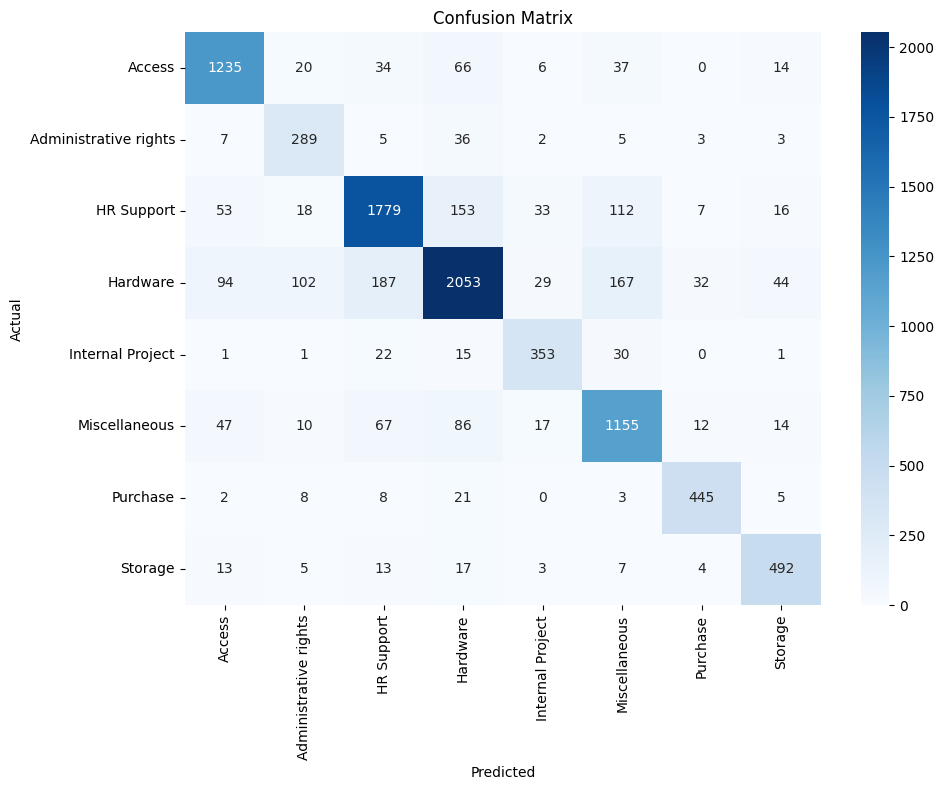

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# Parameters
# -----------------------------
vocab_size = 5000
max_len = 50
embedding_dim = 50
lstm_units = 64
batch_size = 32
epochs = 20

# -----------------------------
# Tokenize text
# -----------------------------
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

# -----------------------------
# Encode labels
# -----------------------------
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_val_int = label_encoder.transform(y_val)

num_classes = len(label_encoder.classes_)

y_train_cat = to_categorical(y_train_int, num_classes)
y_val_cat = to_categorical(y_val_int, num_classes)

# -----------------------------
# Compute class weights
# -----------------------------
class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weights = dict(enumerate(class_weights_values))

print("Class Weights:", class_weights)

# -----------------------------
# Build LSTM model
# -----------------------------
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    ),

    LSTM(
        lstm_units,
        dropout=0.3,
        recurrent_dropout=0.3
    ),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# Early stopping
# -----------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# -----------------------------
# Train model
# -----------------------------
history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# -----------------------------
# Evaluate
# -----------------------------
val_loss, val_acc = model.evaluate(X_val_pad, y_val_cat)
print(f"Validation Accuracy: {val_acc:.4f}")

# -----------------------------
# Predictions
# -----------------------------
y_pred_probs = model.predict(X_val_pad)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_val_cat, axis=1)

# -----------------------------
# Classification Report
# -----------------------------
print(
    classification_report(
        y_true_labels,
        y_pred_labels,
        target_names=label_encoder.classes_
    )
)

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
